In [1]:
import numpy as np

x = np.array([
        [20, 6, 2],
        [16, 3, 6],
        [27, 6, 2],
        [19, 1, 2],
        [24, 4, 2],
        [22, 1, 5],
        [15, 4, 2],
        [18, 4, 2],
        [21, 1, 4],
        [16, 2, 4]
    ])

y = np.array([
        [386],
        [289],
        [393],
        [110],
        [280],
        [167],
        [271],
        [274],
        [148],
        [198]
    ])

def rankk(matrix):
    return np.linalg.matrix_rank(matrix)

def cost(feature_matrix, output_vector):
    pseudo_inverse = np.linalg.pinv(feature_matrix)
    return pseudo_inverse @ output_vector


In [22]:
#A1
print(rankk(x))
print(rankk(y))
print(cost(x,y))

3
1
[[ 1.]
 [55.]
 [18.]]


           Date Month  Day    Price     Open     High      Low   Volume  \
0  Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1  Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2  Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3  Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4  Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   

     Chg%  
0  0.0020  
1  0.0043  
2 -0.0020  
3 -0.0026  
4 -0.0023  

========== Using Numpy ==========
Mean = 1560.6634538152612
Variance = 58496.49239931613

========== Own ==========
Mean = 1560.6634538152598
Variance = 58496.49239931618

========== EXECUTION TIME ==========
NumPy Mean : 6.7800050601363185e-06
Custom Mean : 2.989999484270811e-05
NumPy Variance : 1.8520001322031022e-05
Custom Variance : 9.772999910637737e-05

========== WEDNESDAY ==========
Wednesday Mean = 1550.7060000000001
Population Mean = 1560.6634538152612
Wednesday

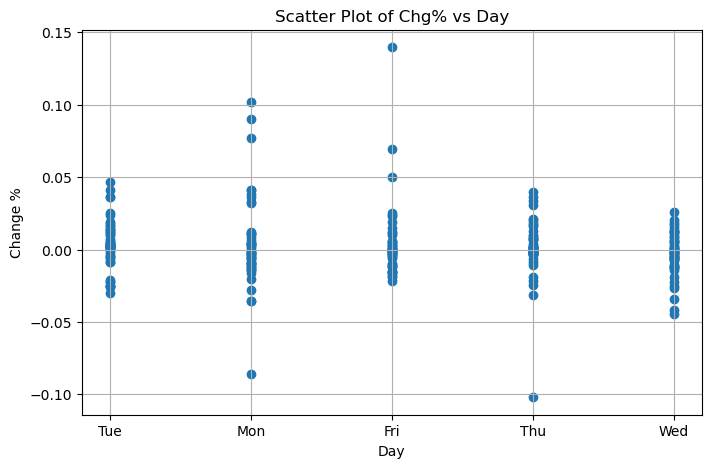

In [17]:
#A3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

filename = "Lab Session Data.xlsx"     
df = pd.read_excel(filename, sheet_name="IRCTC Stock Price")

print(df.head())

df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Chg_num"] = (
    df["Chg%"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

price = df["Price"].values

def my_mean(arr):
    total = 0
    for x in arr:
        total += x
    return total / len(arr)


def my_variance(arr):
    mean = my_mean(arr)

    total = 0

    for x in arr:
        total += (x - mean) ** 2

    return total / len(arr)
    
numpy_mean = np.mean(price)
numpy_variance = np.var(price)

print("\n========== Using Numpy ==========")
print("Mean =", numpy_mean)
print("Variance =", numpy_variance)

own_mean = my_mean(price)
own_variance = my_variance(price)

print("\n========== Own ==========")
print("Mean =", own_mean)
print("Variance =", own_variance)


# -------------------------------
# Execution Time (10 Runs)
# -------------------------------

runs = 10

numpy_mean_time = []
custom_mean_time = []

numpy_var_time = []
custom_var_time = []

for i in range(runs):

    start = time.perf_counter()
    np.mean(price)
    numpy_mean_time.append(time.perf_counter() - start)

    start = time.perf_counter()
    my_mean(price)
    custom_mean_time.append(time.perf_counter() - start)

    start = time.perf_counter()
    np.var(price)
    numpy_var_time.append(time.perf_counter() - start)

    start = time.perf_counter()
    my_variance(price)
    custom_var_time.append(time.perf_counter() - start)

print("\n========== EXECUTION TIME ==========")

print("NumPy Mean :", np.mean(numpy_mean_time))
print("Custom Mean :", np.mean(custom_mean_time))

print("NumPy Variance :", np.mean(numpy_var_time))
print("Custom Variance :", np.mean(custom_var_time))


# -------------------------------
# Wednesday Mean
# -------------------------------

wednesday = df[df["Day"] == "Wed"]

wednesday_mean = wednesday["Price"].mean()

print("\n========== WEDNESDAY ==========")

print("Wednesday Mean =", wednesday_mean)

print("Population Mean =", numpy_mean)

if wednesday_mean > numpy_mean:
    print("Wednesday mean is higher.")
else:
    print("Wednesday mean is lower.")


# -------------------------------
# April Mean
# -------------------------------

april = df[df["Month"] == "Apr"]

april_mean = april["Price"].mean()

print("\n========== APRIL ==========")

print("April Mean =", april_mean)

print("Population Mean =", numpy_mean)

if april_mean > numpy_mean:
    print("April mean is higher.")
else:
    print("April mean is lower.")


# -------------------------------
# Probability of Loss
# -------------------------------

loss = df[df["Chg_num"] < 0]

prob_loss = len(loss) / len(df)

print("\n========== LOSS ==========")

print("Probability of Loss =", prob_loss)


# -------------------------------
# Probability of Profit on Wednesday
# -------------------------------

profit_wed = wednesday[wednesday["Chg_num"] > 0]

prob_profit_wed = len(profit_wed) / len(wednesday)

print("\n========== PROFIT ON WEDNESDAY ==========")

print(prob_profit_wed)


# -------------------------------
# Conditional Probability
# -------------------------------

conditional_probability = len(profit_wed) / len(wednesday)

print("\n========== CONDITIONAL PROBABILITY ==========")

print("P(Profit | Wednesday) =", conditional_probability)


# -------------------------------
# Scatter Plot
# -------------------------------

plt.figure(figsize=(8,5))

plt.scatter(df["Day"], df["Chg_num"])

plt.xlabel("Day")

plt.ylabel("Change %")

plt.title("Scatter Plot of Chg% vs Day")

plt.grid(True)

plt.show()
